### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

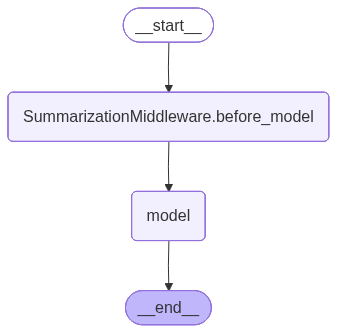

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import SystemMessage, HumanMessage

## agent with Messagebased summarization

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    checkpointer=InMemorySaver(),
    middleware=[SummarizationMiddleware(model="groq:qwen/qwen3-32b",
                                        trigger=("messages", 10),
                                        keep=("messages", 4))],
)
agent

In [3]:
## Thread id

config = {"configurable": {"thread_id": "test1"}}

In [4]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")


Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='2599ddd3-2885-4f88-a9a7-4e0d9939b884'), AIMessage(content='<think>\nOkay, so the user is asking what 2+2 is. Hmm, that seems pretty straightforward. Let me think. I remember learning basic arithmetic in school, right? Addition is one of the fundamental operations. Let me start by recalling the addition table for small numbers. \n\nTwo plus two... Well, if I have two apples and someone gives me two more apples, how many apples do I have in total? That\'s a classic example. So, 2 apples + 2 apples would equal 4 apples. That seems right. \n\nWait, maybe I should visualize it. If I draw two lines and then add two more lines: | | + | | equals ||||. Counting them, that\'s four. Yeah, that checks out. Another way to think about it is using fingers. If I hold up two fingers on one hand and two on the other, how many fingers am I holding up? Two plus two is four, which I can count: 1, 2,

## Token Size

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""


agent=create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("tokens",550),
            keep=("tokens",200),
        ),
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

In [6]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~139 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='0ac6c4bd-e0c9-4d50-bcb2-7541334fb356'), AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to find hotels in Paris. Let me check the available tools. There's a function called search_hotels that takes a city parameter. Since the user specified Paris, I need to call this function with the city set to Paris. I'll make sure the parameters are correctly formatted as JSON within the tool_call tags.\n", 'tool_calls': [{'id': 't273vtx3j', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 155, 'total_tokens': 248, 'completion_time': 0.1206189, 'completion_tokens_details': {'reasoning_tokens': 68}, 'prompt_time': 0.006104001, 'prompt_tokens_details': None, 'queue_time': 0.163473632, 'total_time': 0.126722901}, 'model_na

### Fraction

In [8]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:qwen/qwen3-32b",
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gpt-4o-mini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~70 tokens (0.0547%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='5d4ac70e-e53c-4fba-a430-f74f86469337'), AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking for hotels in Paris. Let me check the tools available. There's a function called search_hotels that takes a city parameter. Since the user specified Paris, I need to call that function with the city set to Paris. I'll make sure the arguments are correctly formatted as JSON within the tool_call tags.\n", 'tool_calls': [{'id': 'ervfs4sp2', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 147, 'total_tokens': 240, 'completion_time': 0.134539031, 'completion_tokens_details': {'reasoning_tokens': 68}, 'prompt_time': 0.00591043, 'prompt_tokens_details': None, 'queue_time': 0.04536949, 'total_time': 0.140449461}, 'model_nam

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `qwen/qwen3-32b` in organization `org_01knk8p9w8eetr2xzgt3h3tp5x` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 4360, Requested 1782. Please try again in 1.42s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

### Human In the Loop MiddleWare

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [13]:
agent=create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)

In [14]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [15]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='f0540aa1-bf44-4cd9-802a-8d791bdbcfba'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, let me see. The user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. I need to check which tool to use here. The available tools are read_email_tool and send_email_tool. Since the action is sending an email, the send_email_tool is the right choice.\n\nLooking at the parameters for send_email_tool, it requires recipient, subject, and body. The user provided all three: recipient is john@test.com, subject is 'Hello', and body is 'How are you?'. I just need to structure these into the function call. Make sure all required fields are included. No missing parameters here. So the tool call should be send_email_tool with those arguments. I'll format the JSON accordingly.\n", 'tool_calls'

In [16]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email has been successfully sent to john@test.com with the subject "Hello" and the message "How are you?". Let me know if there's anything else I can assist you with!


In [17]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='f0540aa1-bf44-4cd9-802a-8d791bdbcfba'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, let me see. The user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. I need to check which tool to use here. The available tools are read_email_tool and send_email_tool. Since the action is sending an email, the send_email_tool is the right choice.\n\nLooking at the parameters for send_email_tool, it requires recipient, subject, and body. The user provided all three: recipient is john@test.com, subject is 'Hello', and body is 'How are you?'. I just need to structure these into the function call. Make sure all required fields are included. No missing parameters here. So the tool call should be send_email_tool with those arguments. I'll format the JSON accordingly.\n", 'tool_calls'

### Reject

In [18]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [19]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [20]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The tool call for sending the email was rejected. Could you please check the parameters or provide additional details to resolve the issue?


In [21]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='232c8d1c-b614-4e07-91a8-9fb622aef77f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's a send_email_tool that requires recipient, subject, and body. All three are required. The parameters are all strings. The user provided all three: recipient is john@test.com, subject is Hello, body is How are you?. So I need to call the send_email_tool with these arguments. No issues here, all required parameters are present. Just format the JSON correctly.\n", 'tool_calls': [{'id': 'jqc1pkdp8', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'comp

### Editing

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [23]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [24]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='a14e2c4c-d923-4499-8f85-f1d5c3909108'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to wrong@email.com with the subject 'Test' and body 'Hello'. Let me check the tools available.\n\nThere's a send_email_tool function. It requires recipient, subject, and body. The parameters are all there: recipient is wrong@email.com, subject is 'Test', and body is 'Hello'. I need to make sure all required fields are included. Yep, all three are present. So I should call send_email_tool with these arguments. No need to use the read_email_tool here since the task is about sending, not reading. Everything looks good. Let's structure the tool call accordingly.\n", 'tool_calls': [{'id': '4htd1qmdk', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name':

In [25]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: The email has been successfully sent to correct@email.com with the subject "Corrected Subject". Let me know if you need any further assistance!


In [26]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='a14e2c4c-d923-4499-8f85-f1d5c3909108'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to wrong@email.com with the subject 'Test' and body 'Hello'. Let me check the tools available.\n\nThere's a send_email_tool function. It requires recipient, subject, and body. The parameters are all there: recipient is wrong@email.com, subject is 'Test', and body is 'Hello'. I need to make sure all required fields are included. Yep, all three are present. So I should call send_email_tool with these arguments. No need to use the read_email_tool here since the task is about sending, not reading. Everything looks good. Let's structure the tool call accordingly.\n", 'tool_calls': [{'id': '4htd1qmdk', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name':